In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [8]:
df = pd.read_csv('../data/addis_house_price.csv')

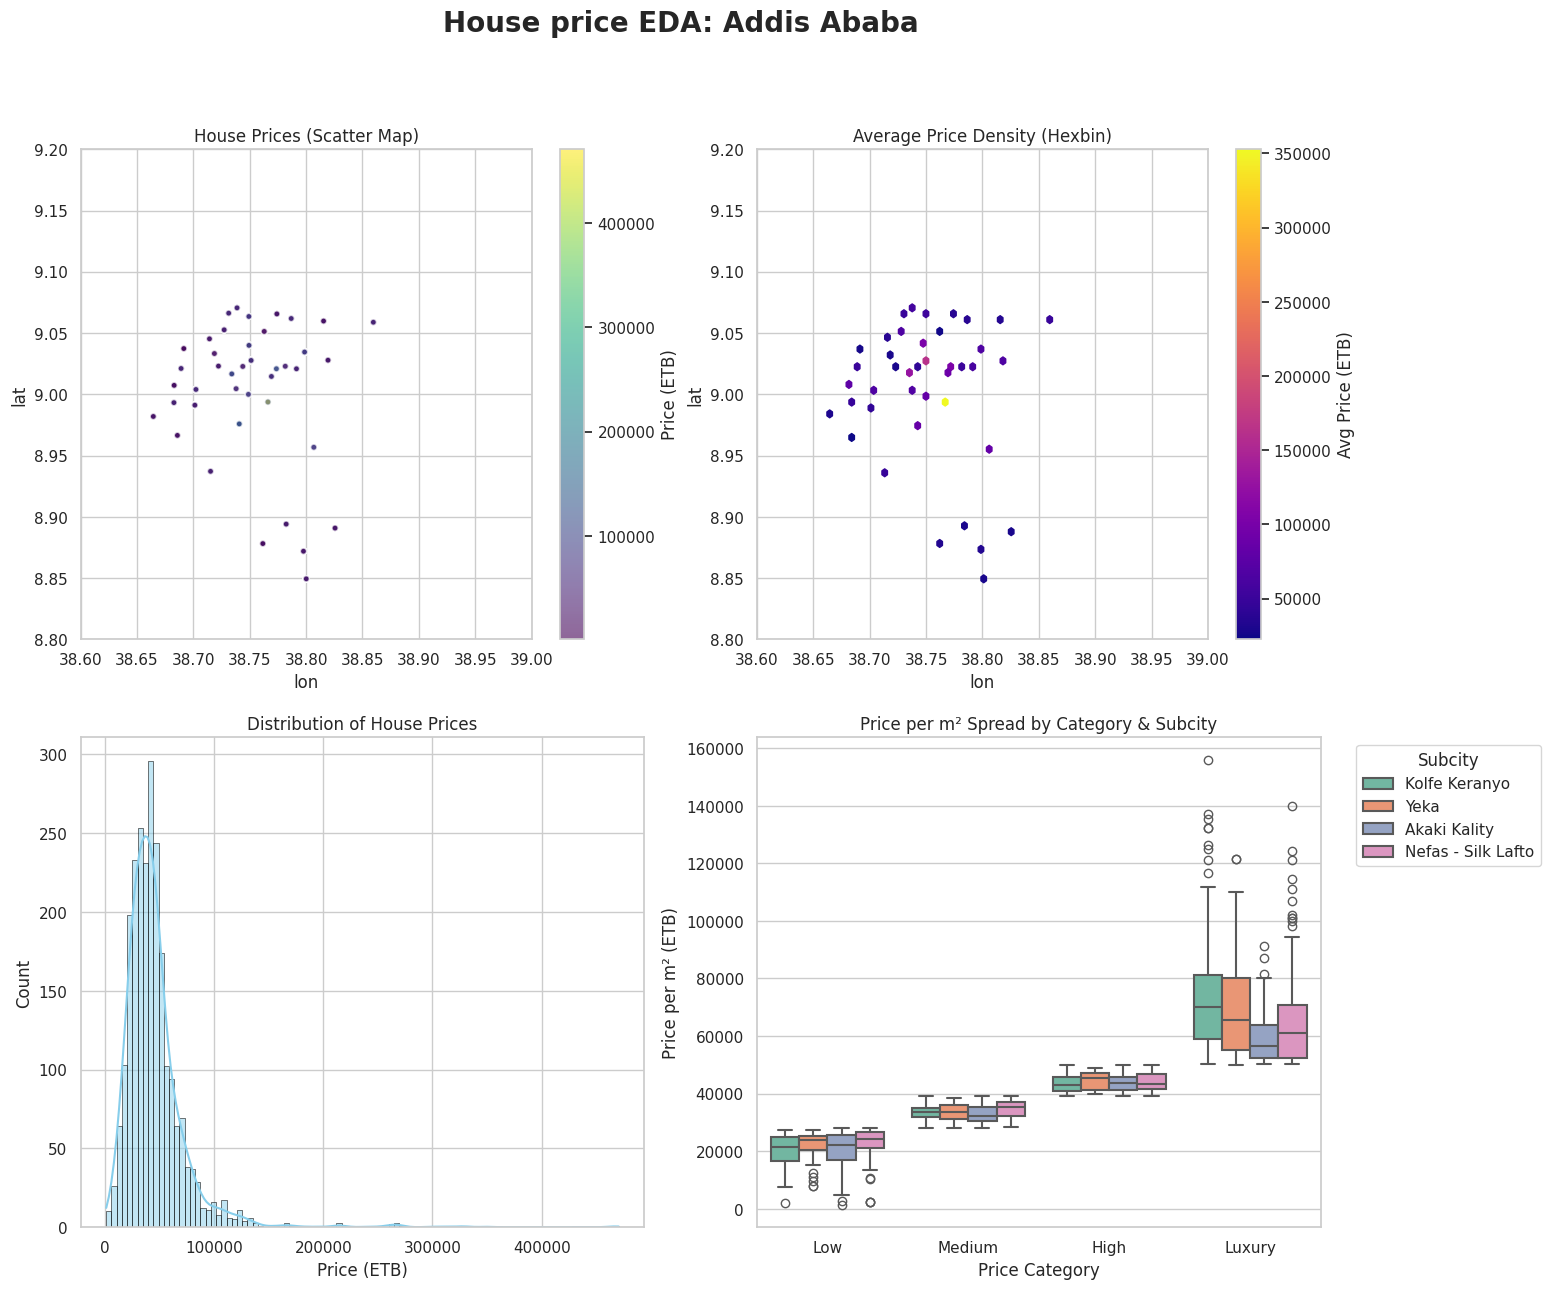

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('House price EDA: Addis Ababa', fontsize=20, fontweight='bold')

ax1 = axes[0, 0]
scatter = ax1.scatter(
    df['lon'], df['lat'],
    c=df['price_per_sqm'],
    cmap='viridis',
    alpha=0.6,
    s=20,
    edgecolors='w'
)

ax1.set_title('House Prices (Scatter Map)')
ax1.set_xlabel('lon')
ax1.set_ylabel('lat')
ax1.set_xlim(38.6, 39.0)
ax1.set_ylim(8.8, 9.2)
plt.colorbar(scatter, ax=ax1, label='Price (ETB)')

ax2 = axes[0, 1]
hb = ax2.hexbin(
    df['lon'], df['lat'],
    C=df['price_per_sqm'],
    gridsize=40,
    cmap='plasma',
    mincnt=1,
    reduce_C_function=np.mean
)

ax2.set_title('Average Price Density (Hexbin)')
ax2.set_xlabel('lon')
ax2.set_ylabel('lat')
ax2.set_xlim(38.6, 39.0)
ax2.set_ylim(8.8, 9.2)
plt.colorbar(hb, ax=ax2, label='Avg Price (ETB)')

ax3 = axes[1, 0]
sns.histplot(data=df, x='price_per_sqm', kde=True, ax=ax3, color='skyblue', edgecolor='black')
ax3.set_title('Distribution of House Prices')
ax3.set_xlabel('Price (ETB)')
ax3.set_ylabel('Count')

top_subcities = df['subcity'].value_counts().nlargest(4).index
df_filtered = df[df['subcity'].isin(top_subcities)]

df_filtered['price_cat'] = pd.qcut(df_filtered['price_per_sqm'], q=4, labels=['Low', 'Medium', 'High', 'Luxury'])

ax4 = axes[1, 1]
sns.boxplot(
    data=df_filtered,
    x='price_cat',
    y='price_per_sqm',
    hue='subcity',
    palette='Set2',
    ax=ax4,
    dodge=True,         
    linewidth=1.5
)

ax4.set_title('Price per m² Spread by Category & Subcity')
ax4.set_xlabel('Price Category')
ax4.set_ylabel('Price per m² (ETB)')
ax4.legend(title='Subcity', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.tick_params(axis='x', rotation=0)
